In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
1/(12*66)

0.0012626262626262627

In [3]:
#the temperature fit
#def tempfit(t):
 #   fitt = 28.19874*(1 + 0.2476246*np.cos((np.pi/6)*(0.8089651*t-5.192219)))
  #  return fitt
#def tempfit(t):
 #   cost1 =  -3.568*np.cos((np.pi/6)*1.13937*t)
  #  cost2 =  7.96*np.cos(2*(np.pi/6)*1.13937*t) 
   # sint1 = -2.776*np.sin((np.pi/6)*1.13937*t)
    #sint2 = -2.278*np.sin(2*(np.pi/6)*1.13937*t)
                        
   # fitt = 30.666 -3.568*np.cos((np.pi/6)*1.13937*t) + 7.96*np.cos(2*(np.pi/6)*1.13937*t) -2.776*np.sin((np.pi/6)*1.13937*t) -2.278*np.sin(2*(np.pi/6)*1.13937*t)
    #fitt = 30.666 + cost1 + cost2 + sint1 + sint2
    #return fitt

In [4]:
def tempfit(t):
     cost1 =  -2.94069*np.cos((np.pi/6)*(-1.180806)*t)
     cost2 =  1.57860*np.cos(2*(np.pi/6)*(-1.180806)*t)
     cost3 = 0.640225*np.cos(3*(np.pi/6)*(-1.180806)*t)
     sint1 = 3.00629*np.sin((np.pi/6)*(-1.180806)*t)
     sint2 = 1.93711*np.sin(2*(np.pi/6)*(-1.180806)*t)
     sint3 = 1.5506*np.sin(3*(np.pi/6)*(-1.180806)*t)
                        
   # fitt = 30.666 -3.568*np.cos((np.pi/6)*1.13937*t) + 7.96*np.cos(2*(np.pi/6)*1.13937*t) -2.776*np.sin((np.pi/6)*1.13937*t) -2.278*np.sin(2*(np.pi/6)*1.13937*t)
     fitt = 30.9144 + cost1 + cost2 + cost3 + sint1 + sint2 + sint3
     return fitt

In [5]:
#the rainfall function
#def rainffit(t):
   # t_mod = t % 12  # Get month position in annual cycle
    #t_mod = 12 if t_mod == 0 else t_mod  # Handle December
  #  if 5 <= t_mod <= 10:  # Wet season (May-Oct)
   #     return  22.91487*(1 + 1.048219*np.cos((np.pi/6)*(2.469001*t_mod-7.815061)))
        #return rainfit(t)
   # else:  # Dry season (Nov-Apr)
    #    return 0.0
def rainffit(t): 
    cosr1 = 14.158*np.cos((np.pi/6)*1.321*t)
    cosr2 =  2.0275*np.cos(2*(np.pi/6)*1.1321*t)
    cosr3 =  - 4.0865*np.cos(3*(np.pi/6)*1.321*t)
    sinr1 = -13.841*np.sin((np.pi/6)*1.321*t)
    sinr2 = -11.3745*np.sin(2*(np.pi/6)*1.321*t) 
    sinr3 = - 4.2508*np.sin(3*(np.pi/6)*1.321*t)
    rfft = 11.281 + cosr1 + cosr2 + cosr3 +sinr1 + sinr2 + sinr3
   # rfft = 11.281  + 14.158*np.cos((np.pi/6)*1.321*t) + 2.0275*np.cos(2*(np.pi/6)*1.1321*t) - 4.0865*np.cos(3*(np.pi/6)*1.321*t) -13.841*np.sin((np.pi/6)*1.321*t) -11.3745*np.sin(2*(np.pi/6)*1.321*t) - 4.2508*np.sin(3*(np.pi/6)*1.321*t)
    return rfft

In [6]:
#the temperature and rainfall dependent parameters
#the vectors bitting rate
def bit(t): 
    theta = -0.00014*((tempfit(t))**2) + 0.027*(tempfit(t)) - 0.322
    return theta

#the rate of vectors laying eggs
def eggn(t):
    b_v = -0.153*((tempfit(t))**2) + 8.61*(tempfit(t)) - 0.487
    return b_v
#immature vectors deaths
def dj(t):
    mu_vj = ((1)/(8.560 + 20.654*((1 + ((tempfit(t))/(19.759))**(6.827))**(-1))))
    return mu_vj
#matrue vectors deaths
def da(t):
    mu_va = -np.log10(- 0.000828*((tempfit(t))**2) + 0.0367*(tempfit(t)) + 0.522)
    return mu_va

In [7]:
#the rate of immature vectors become mature
#number of laid eggs
def EFD(T):
    egga = -0.153*(T**2) + 8.61*T - 97.7
    return egga
def Pe(R):
    p_e = ((4*0.9*(R+0))/((120)**2))*(120 - R)
    return p_e
def Plr(R):
    p_l = ((4*0.25*(R+0))/((120)**2))*(120 - R)
    return p_l
def Pp(R):
    p_p =  ((4*0.75*(R+0))/((120)**2))*(120 - R)
    return p_p
def Plt(T):
    p_ll = np.exp(-(0.0554*T - 0.0673))
    return p_ll
def Pl(T,R):
    return Plt(T)*Plr(R)

def f_ea(T):
    pro = (1)/((-0.00094*((T)**2) + 0.049*(T) - 0.0552))
    return pro

def r_time(t):
    r_at = (EFD((tempfit(t)))*Pe(rainffit(t))* Pl(tempfit(t), rainffit(t))*Pp(tempfit(t)))/((da(tempfit(t)))*f_ea((tempfit(t))))
    return r_at

In [8]:
from scipy.integrate import quad
#theta, error = quad(bit,0,12)
#b_v, error = quad(eggn,0,12)
#mv_j, error = quad(dj,0,12)
#mv_a, error = quad(da, 0,12)
#r_a, error = quad(r_time, 0,12)
#print((1/12)*theta, (1/12)*b_v, (1/12)*mv_j, (1/12)*mv_a, (1/12)*r_a)

theta, error = quad(bit,1,12)
b_v, error = quad(eggn,1,12)
mv_j, error = quad(dj,1,12)
mv_a, error = quad(da, 1,12)
r_a, error = quad(r_time, 1,12)
print((1/12)*theta, (1/12)*b_v, (1/12)*mv_j, (1/12)*mv_a, (1/12)*r_a)

0.3356813443283674 107.62640160666008 0.0918440638173853 0.06078844891911622 1.0589664359332174


In [9]:
#the parameters 
mh = 0.001262
pi_h = 1000000*mh
B_h = 0.595
B_v = 0.544
epsilon = 0.4
chi = 0.003
alpha_a = 0.03
alpha_z = 1.0
vphi = 0.8
delta = 0.08
gamma = 0.001
xi = 0.02
sigma1 = 0.32
sigma2 = (sigma1)/(3)
tau = 0.04
K_v = 8000000

#temperature and rainfall parameters 
print(pi_h)
theta = 0.33568
b_v =   107.62640
r = 1.058966
mu_vj = 0.091844
mu_va = 0.060788

k_0 = ((sigma2 + tau)/(sigma2 + tau + xi))
gam2 = (gamma*xi)/(sigma2 + tau)
#the values of L's for the basic reproduction number R_0;
L1 = (alpha_a + mh)
L2 = (alpha_z*(1 - sigma1) + delta + mh)
L3 = (mu_va + gam2)
A_v = (r*b_v)/((r + mu_vj + gam2)*(mu_va + gam2))

#%The basic reproduction number R_0
Q1 = ((theta**2)*((k_0)**2)*B_h*B_v*mh*(1 - epsilon)*r*K_v*(1 - 1/A_v)*(vphi*L2 + (1 - chi)*alpha_a))/(pi_h*L1*L2*((L3)**2))
Q2 = ((theta**2)*((k_0)**2)*B_h*B_v*mh*epsilon*r*K_v*(1 - 1/A_v)*(L1))/(pi_h*L1*L2*((L3)**2))
R_0 = np.sqrt(Q1 + Q2)
print(np.round(R_0,4))

1262.0
32.7356


C:\Users\Mohamed Salah\AppData\Local\Temp\ipykernel_20456\1467073474.py:48: UserWarning: The following kwargs were not used by contour: 'camp'
  plt.contourf(X1, Y1, R_0, camp = 'Blues')  # Filled contour plot


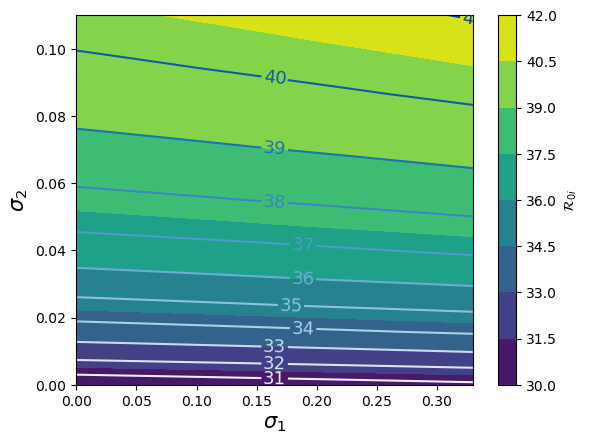

In [18]:
#the parameters 
mh = 0.001262
pi_h = 1000000*mh
#B_h = 0.24
#B_v = 0.022
B_h = 0.595
B_v = 0.544
epsilon = 0.4
chi = 0.001
alpha_a = 0.028
alpha_z = 0.03
vphi = 0.8
delta = 0.08
gamma = 0.001
xi = 0.02
sigma1 = 0.313
sigma2 = (sigma1)/(3)
tau = 0.04
K_v = 8000000

setsigma1 = np.linspace(0.0, 0.33,15)
setsigma2 = np.linspace(0.0, 0.33/3,15)
#temperature and rainfall parameters 

theta = 0.33568
b_v =   107.62640
r = 1.058966
mu_vj = 0.091844
mu_va = 0.060788
X1, Y1 = np.meshgrid(setsigma1, setsigma2)

k_0 = ((Y1 + tau)/(Y1 + tau + xi))
gam2 = (gamma*xi)/(Y1 + tau)
#the values of L's for the basic reproduction number R_0;
L1 = (alpha_a + mh)
L2 = (alpha_z*(1 - X1) + delta + mh)
L3 = (mu_va + gam2)
A_v = (r*b_v)/((r + mu_vj + gam2)*(mu_va + gam2))



#%The basic reprodcution number R_0
Q1 = ((theta**2)*((k_0)**2)*B_h*B_v*mh*(1 - epsilon)*r*K_v*(1 - 1/A_v)*(vphi*L2 + (1 - chi)*alpha_a))/(pi_h*L1*L2*((L3)**2))
Q2 = ((theta**2)*((k_0)**2)*B_h*B_v*mh*epsilon*r*K_v*(1 - 1/A_v)*(L1))/(pi_h*L1*L2*((L3)**2))
R_0 = np.sqrt(Q1 + Q2)
contours = plt.contour(X1, Y1, R_0, levels=10, cmap='Blues')
plt.clabel(contours, inline=True, fontsize=13)# Add contour labels
plt.contourf(X1, Y1, R_0, camp = 'Blues')  # Filled contour plot
plt.colorbar(label='$\mathcal{R}_{0i}$')  # Add colorbar
plt.xlabel('$\sigma_{1}$', fontsize=15)
plt.ylabel('$\sigma_{2}$', fontsize=15)
#plt.title('Contour Plot of R0 vs Two Parameter')
plt.savefig('cont1ut.jpg')
# Show the plot
plt.show()

C:\Users\Mohamed Salah\AppData\Local\Temp\ipykernel_20456\3513817152.py:51: UserWarning: The following kwargs were not used by contour: 'camp'
  plt.contourf(T1, T2, R_0, camp = 'Blues')  # Filled contour plot


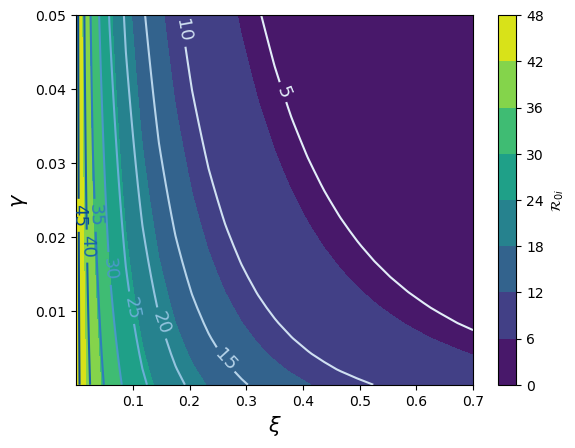

In [19]:
#the parameters 
mh = 0.001262
pi_h = 1000000*mh
#B_h = 0.24
#B_v = 0.022
B_h = 0.595
B_v = 0.544
epsilon = 0.4
chi = 0.001
alpha_a = 0.028
alpha_z = 0.03
vphi = 0.8
delta = 0.08
gamma = 0.001
xi = 0.02
sigma1 = 0.313
sigma2 = (sigma1)/(3)
tau = 0.04
K_v = 8000000


####
setgamma = np.linspace(0.0001, 0.05, 25)
setxi = np.linspace(0.0001, 0.7, 25)

T1, T2 = np.meshgrid(setxi, setgamma)
#temperature and rainfall parameters 

theta = 0.33568
b_v =   107.62640
r = 1.058966
mu_vj = 0.091844
mu_va = 0.060788

k_0 = ((sigma2 + tau)/(sigma2 + tau + T1))
gam2 = (T2*T1)/(sigma2 + tau)
#the values of L's for the basic reproduction number R_0;
L1 = (alpha_a + mh)
L2 = (alpha_z*(1 - sigma1) + delta + mh)
L3 = (mu_va + gam2)
A_v = (r*b_v)/((r + mu_vj + gam2)*(mu_va + gam2))



#%The basic reprodcution number R_0
Q1 = ((theta**2)*((k_0)**2)*B_h*B_v*mh*(1 - epsilon)*r*K_v*(1 - 1/A_v)*(vphi*L2 + (1 - chi)*alpha_a))/(pi_h*L1*L2*((L3)**2))
Q2 = ((theta**2)*((k_0)**2)*B_h*B_v*mh*epsilon*r*K_v*(1 - 1/A_v)*(L1))/(pi_h*L1*L2*((L3)**2))
R_0 = np.sqrt(Q1 + Q2)
contours = plt.contour(T1, T2, R_0, levels=10, cmap='Blues')
plt.clabel(contours, inline=True, fontsize=13)# Add contour labels
plt.contourf(T1, T2, R_0, camp = 'Blues')  # Filled contour plot
plt.colorbar(label='$\mathcal{R}_{0i}$')  # Add colorbar
plt.xlabel('$\\xi$', fontsize=15)
plt.ylabel('$\gamma$', fontsize=15)
#plt.title('Contour Plot of R0 vs Two Parameter')
plt.savefig('cont2ut.jpg')
# Show the plot
plt.show()

In [15]:
import numpy as np

def latin_hypercube_sampling(num_samples, param_ranges):
    num_params = len(param_ranges)
    samples = np.zeros((num_samples, num_params))

    for i, (param, (low, high)) in enumerate(param_ranges.items()):
        # Divide range into equal probability intervals
        intervals = np.linspace(low, high, num_samples + 1)
        # Sample points within each interval randomly
        samples[:, i] = np.random.uniform(intervals[:-1], intervals[1:])
        # Shuffle rows to ensure randomness
        np.random.shuffle(samples[:, i])

    return samples

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import kendalltau

params = {
    'pi' : [1000, 20000],#0
    'Bh':  [0.072, 0.64],#1
    'bith' : [0.1878, 0.4545],#2
    'mh' : [0.0010416, 0.001388],#3
    'alpa' :  [0.001,0.03],#4
    'eps' : [0.3, 0.5],#5
    'ch' :  [0.00001, 0.005],#6
    'alps' :  [1.0, 10],#7
    'sig1' : [0, 0.33],#8
    'dlt' : [0.00001,0.1],#9
    'K_v' : [3*(10)**6, 50*(10)**6],#10
    'Bv' : [0.072, 0.64],#11
    'vph' :  [0.001, 0.9],#12
    'gam' : [0.0001, 0.07],#13
    'eggl' : [113.0600, 120.6435],#14
    'r' : [0.0, 10.7196],#15
    'dvj' : [0.06087, 0.11167],#16
    'dva' :[0.032143, 0.10325],#17
    'xi' : [0.001, 0.8],#18
    'tau' : [0.0001, 0.5],#19
    'sig2' : [0.0, 0.33/3]#20
}
num_samples = 1000
lhs_sam = latin_hypercube_sampling(num_samples, params)

k_0 = ((lhs_sam[:,20] + lhs_sam[:,19])/(lhs_sam[:,20] + lhs_sam[:,19] + lhs_sam[:,8]))
gam2 = (lhs_sam[:,13]*lhs_sam[:,18])/(lhs_sam[:,20] + lhs_sam[:,19])
#the values of L's for the basic reproduction number R_0;
L1 = (lhs_sam[:,4] + lhs_sam[:,3])
L2 = (lhs_sam[:,7]*(1 - lhs_sam[:,8]) + lhs_sam[:,9] + lhs_sam[:,3])
L3 = (lhs_sam[:,17] + gam2)
A_v = (lhs_sam[:,15]*lhs_sam[:,14])/((lhs_sam[:,15] + lhs_sam[:,16] + gam2)*(lhs_sam[:,17] + gam2))



#%The basic reprodcution number R_0
Q1 = (((lhs_sam[:,2])**2)*((k_0)**2)*lhs_sam[:,1]*lhs_sam[:,11]*lhs_sam[:,3]*(1 - lhs_sam[:,5])*lhs_sam[:,15]*lhs_sam[:,10]*(1 - 1/A_v)*(lhs_sam[:,12]*L2 + (1 - lhs_sam[:,6])*lhs_sam[:,4]))/(lhs_sam[:,0]*L1*L2*((L3)**2))
Q2 = (((lhs_sam[:,2])**2)*((k_0)**2)*lhs_sam[:,1]*lhs_sam[:,11]*lhs_sam[:,3]*lhs_sam[:,5]*lhs_sam[:,15]*lhs_sam[:,10]*(1 - 1/A_v)*(L1))/(lhs_sam[:,0]*L1*L2*((L3)**2))
R_0 = np.sqrt(Q1 + Q2)
#print(A_v)
#print(np.round(R_0,4))
df = pd.DataFrame(lhs_sam, columns=params.keys())
df["Rn"] = R_0
spearman_results = {param: spearmanr(df[param], df["Rn"])[0] for param in params.keys()}


print("Spearman correlation coefficients:")
for param, spearman_coeff in spearman_results.items():
    print(f"{param}: {spearman_coeff:.4f}")

Spearman correlation coefficients:
pi: -0.2154
Bh: 0.1987
bith: 0.2573
mh: 0.0597
alpa: -0.2346
eps: 0.0430
ch: -0.0022
alps: -0.0169
sig1: -0.1556
dlt: -0.0492
K_v: 0.2985
Bv: 0.2139
vph: 0.3340
gam: -0.1961
eggl: -0.0808
r: 0.3270
dvj: 0.0437
dva: -0.1759
xi: -0.1915
tau: 0.3903
sig2: 0.0028


In [17]:
prcc_results = {param:  kendalltau(df[param],df["Rn"])[0] for param in params.keys()}
print("PRCC correlation coefficients:")
for param, kendalltau_coeff in prcc_results.items():
    print(f"{param}: {kendalltau_coeff:.4f}")

PRCC correlation coefficients:
pi: -0.1450
Bh: 0.1328
bith: 0.1736
mh: 0.0393
alpa: -0.1583
eps: 0.0287
ch: -0.0020
alps: -0.0114
sig1: -0.1031
dlt: -0.0326
K_v: 0.2008
Bv: 0.1436
vph: 0.2285
gam: -0.1312
eggl: -0.0547
r: 0.2221
dvj: 0.0288
dva: -0.1188
xi: -0.1281
tau: 0.2700
sig2: 0.0018


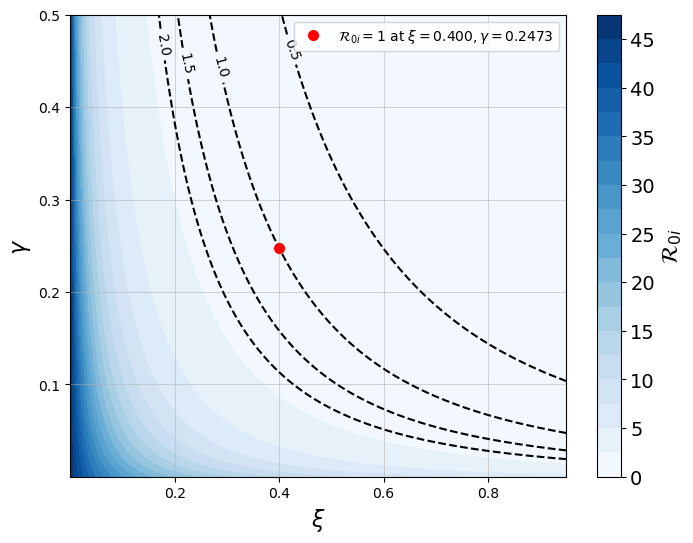

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Parameters
mh = 0.001282
pi_h = 1000000 * mh
B_h = 0.595
B_v = 0.544
epsilon = 0.4
chi = 0.001
alpha_a = 0.028
alpha_z = 0.03
vphi = 0.8
delta = 0.08
sigma1 = 0.313
sigma2 = sigma1 / 3
tau = 0.04
K_v = 8000000
theta = 0.33568
b_v =   107.62640
r = 1.058966
mu_vj = 0.091844
mu_va = 0.060788

# Define R0 function
def calculate_R0(xi, gamma):
    k_0 = (sigma2 + tau) / (sigma2 + tau + xi)
    gam2 = (gamma * xi) / (sigma2 + tau)
    L1 = alpha_a + mh
    L2 = alpha_z * (1 - sigma1) + delta + mh
    L3 = mu_va + gam2
    A_v = (r * b_v) / ((r + mu_vj + gam2) * (mu_va + gam2))
    
    term_Av = (1 - 1/A_v)
    Q1 = ((theta**2) * (k_0**2) * B_h * B_v * mh * (1 - epsilon) * r * K_v * term_Av * (vphi * L2 + (1 - chi) * alpha_a)) / (pi_h * L1 * L2 * (L3**2))
    Q2 = ((theta**2) * (k_0**2) * B_h * B_v * mh * epsilon * r * K_v * term_Av * L1) / (pi_h * L1 * L2 * (L3**2))
    
    val = Q1 + Q2
    return np.sqrt(val) if val > 0 else 0

# Set bounds
setxi = np.linspace(0.0001, 0.95, 200)
setgamma = np.linspace(0.0001, 0.5, 200)
T1, T2 = np.meshgrid(setxi, setgamma)

# Calculate R0 grid
R_0 = np.vectorize(calculate_R0)(T1, T2)

# Specific point where R0 = 1
target_xi = 0.4
# Solve for gamma given xi=0.4
target_gamma = fsolve(lambda g: calculate_R0(target_xi, g) - 1, 0.2)[0]

# Plotting
plt.figure(figsize=(8, 6))
contours = plt.contour(T1, T2, R_0, levels=[0.5, 1.0, 1.5, 2.0], colors='black', linestyles='dashed')
plt.clabel(contours, inline=True, fontsize=10)
plt.contourf(T1, T2, R_0, levels=20, cmap='Blues')
#plt.colorbar(label='$\mathcal{R}_{0i}$')
cbar = plt.colorbar()
cbar.set_label('$\\mathcal{R}_{0i}$', fontsize=16)   # increase label size
cbar.ax.tick_params(labelsize=14)   
# Highlight the point R0 = 1 with correctly formatted label
# Note the use of double curly braces {{ }} around R and 0
label_text = fr'$\mathcal{{R}}_{{0i}}=1$ at $\xi={target_xi:.3f}, \gamma={target_gamma:.4f}$'
plt.plot(target_xi, target_gamma, 'ro', markersize=7, label=label_text)

plt.xlabel('$\\xi$', fontsize=16)
plt.ylabel('$\\gamma$', fontsize=16)
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.savefig('thres.jpg')
plt.show()